In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
url = "https://raw.githubusercontent.com/nurfnick/Data_Viz/main/Data_Sets/AB_NYC_2019.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.shape

(48895, 16)

In [ ]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df_clean = df.copy()

print("Copy created successfully!")

Copy created successfully!


In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean['name'] = df_clean['name'].fillna('Unknown Listing')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown Host')

In [ ]:
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [ ]:
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'])

In [ ]:
df_clean.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
room_counts = df_clean['room_type'].value_counts()

room_counts

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


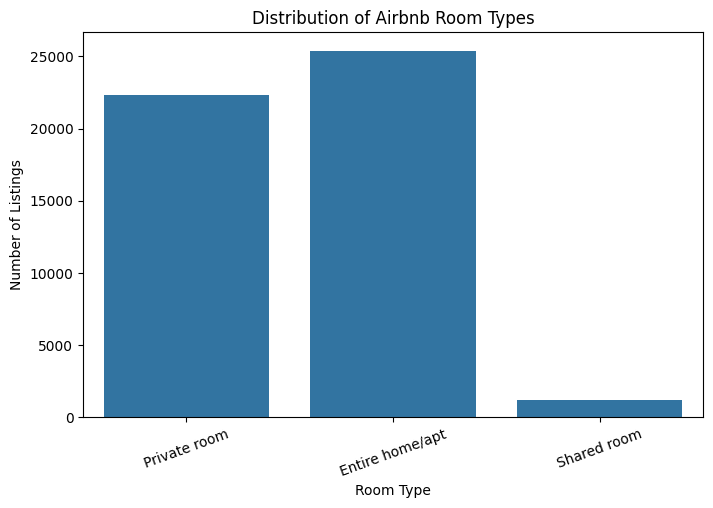

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_clean, x='room_type')

plt.title('Distribution of Airbnb Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=20)

plt.show()

In [ ]:
print("Average price:", df_clean['price'].mean())
print("Minimum price:", df_clean['price'].min())
print("Maximum price:", df_clean['price'].max())

Average price: 152.7206871868289
Minimum price: 0
Maximum price: 10000


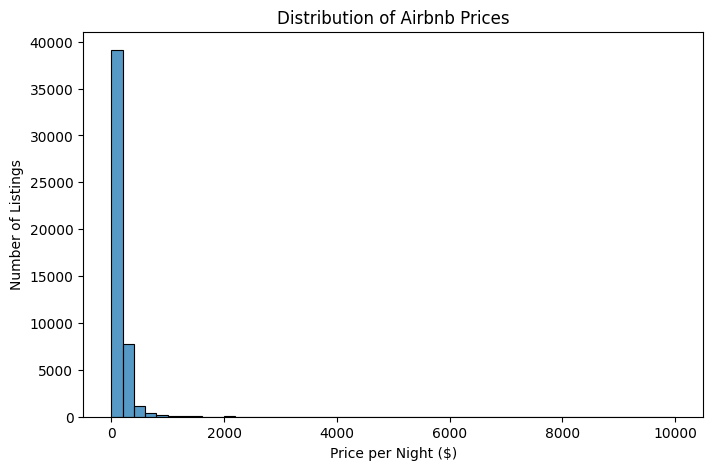

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean['price'], bins=50)

plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price per Night ($)')
plt.ylabel('Number of Listings')

plt.show()

In [ ]:
price_99 = df_clean['price'].quantile(0.99)

print("99th percentile price:", price_99)

99th percentile price: 799.0


In [ ]:
df_price = df_clean[df_clean['price'] <= price_99]

print("Original listings:", len(df_clean))
print("Listings after price filtering:", len(df_price))

Original listings: 48895
Listings after price filtering: 48421


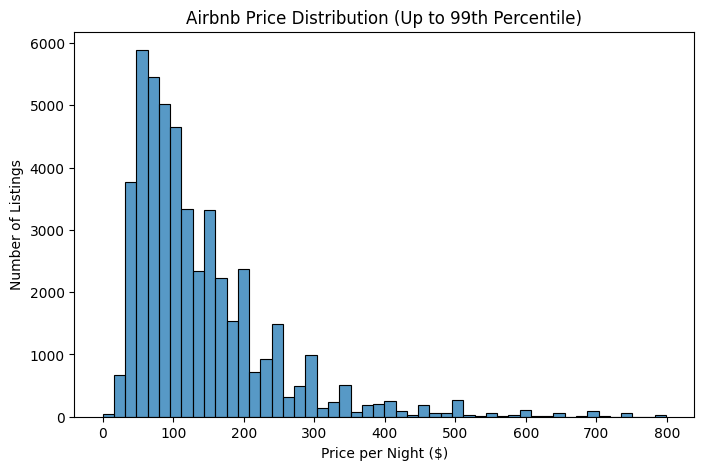

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df_price['price'], bins=50)

plt.title('Airbnb Price Distribution (Up to 99th Percentile)')
plt.xlabel('Price per Night ($)')
plt.ylabel('Number of Listings')

plt.show()

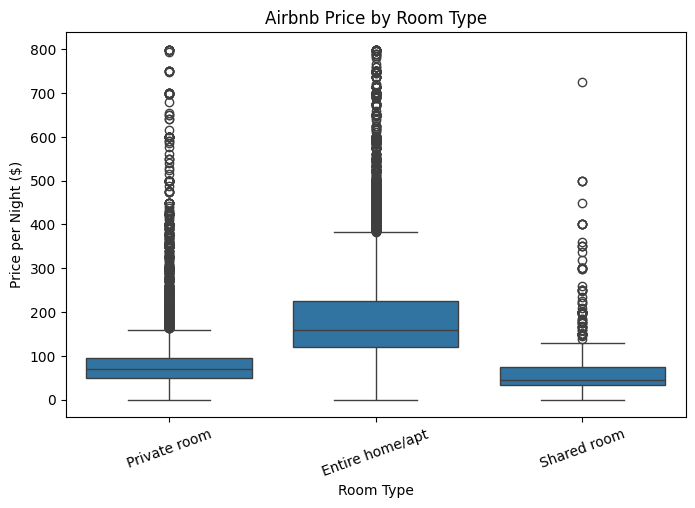

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_price, x='room_type', y='price')

plt.title('Airbnb Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price per Night ($)')
plt.xticks(rotation=20)

plt.show()

In [ ]:
neighbourhood_counts = df_clean['neighbourhood'].value_counts().head(10)

neighbourhood_counts

,count
neighbourhood,
Williamsburg,3920
Bedford-Stuyvesant,3714
Harlem,2658
Bushwick,2465
Upper West Side,1971
Hell's Kitchen,1958
East Village,1853
Upper East Side,1798
Crown Heights,1564


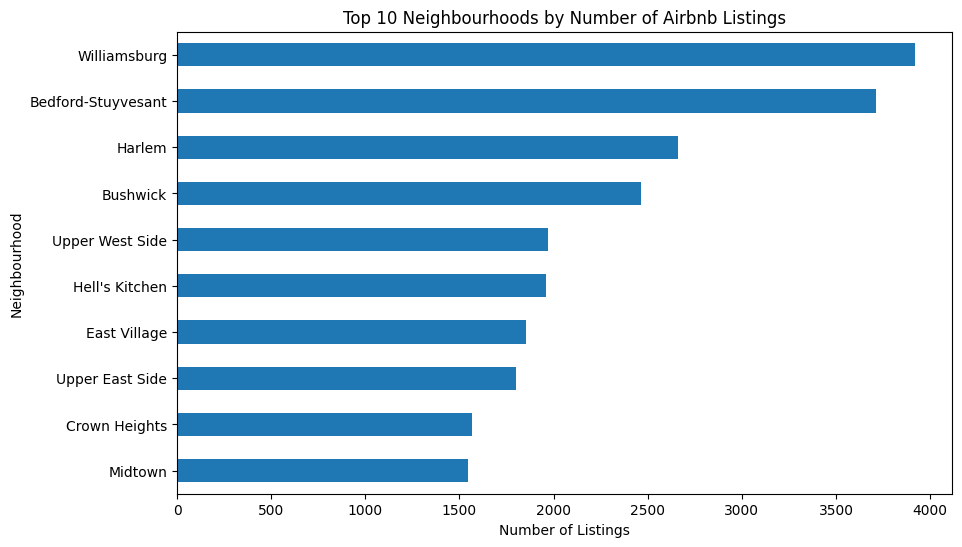

In [ ]:
plt.figure(figsize=(10,6))

neighbourhood_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Neighbourhoods by Number of Airbnb Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')

plt.show()

In [ ]:
avg_price_neighbourhood = (
      df_price.groupby('neighbourhood')['price']
          .mean()
              .sort_values(ascending=False)
                  .head(10)
                  )

avg_price_neighbourhood

,price
neighbourhood,
Woodrow,700.000000
Tribeca,295.647436
NoHo,276.246753
Neponsit,274.666667
Flatiron District,258.162162
Midtown,255.751830
Willowbrook,249.000000
SoHo,229.833828
West Village,224.897019


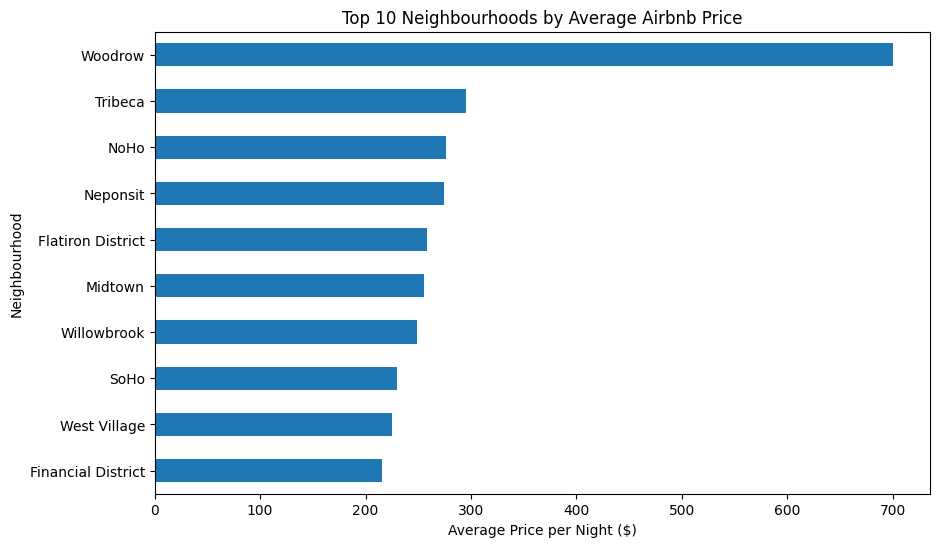

In [ ]:
plt.figure(figsize=(10,6))

avg_price_neighbourhood.sort_values().plot(kind='barh')

plt.title('Top 10 Neighbourhoods by Average Airbnb Price')
plt.xlabel('Average Price per Night ($)')
plt.ylabel('Neighbourhood')

plt.show()

In [ ]:
group_counts = df_clean['neighbourhood_group'].value_counts()

group_counts

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


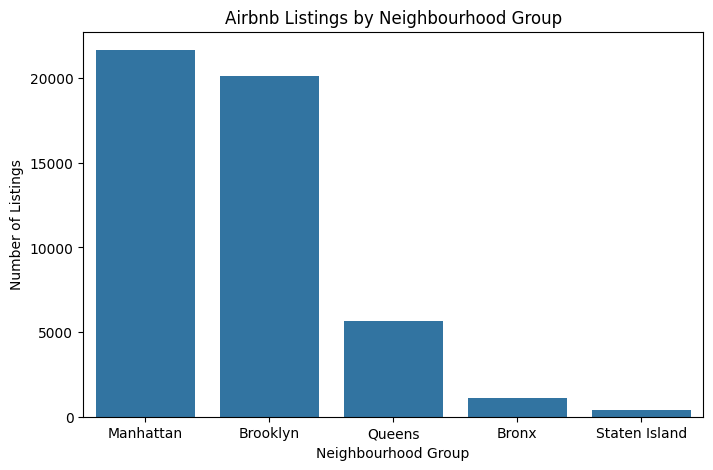

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='neighbourhood_group',
    order=group_counts.index
)

plt.title('Airbnb Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')

plt.show()

In [ ]:
group_avg_price = (
      df_price.groupby('neighbourhood_group')['price']
          .mean()
              .sort_values(ascending=False)
              )

group_avg_price

,price
neighbourhood_group,
Manhattan,172.893774
Brooklyn,115.869357
Staten Island,94.241192
Queens,94.104779
Bronx,83.785846


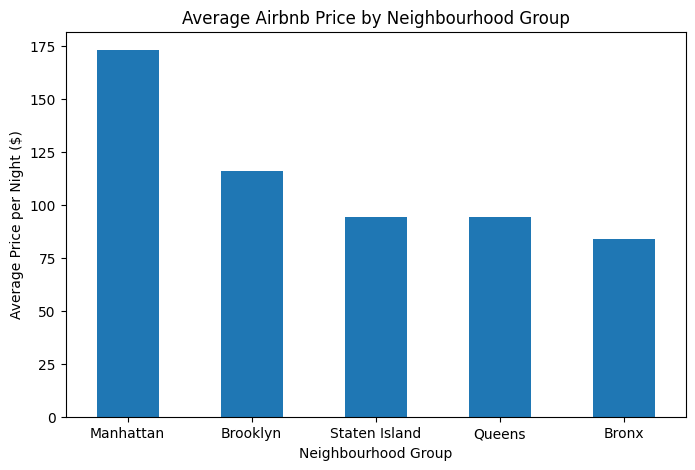

In [ ]:
plt.figure(figsize=(8,5))

group_avg_price.plot(kind='bar')

plt.title('Average Airbnb Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price per Night ($)')
plt.xticks(rotation=0)

plt.show()

In [ ]:
top_reviewed = (
      df_clean[['name', 'neighbourhood', 'room_type', 'number_of_reviews', 'price']]
          .sort_values('number_of_reviews', ascending=False)
              .head(10)
              )

top_reviewed

,name,neighbourhood,room_type,number_of_reviews,price
11759,Room near JFK Queen Bed,Jamaica,Private room,629,47
2031,Great Bedroom in Manhattan,Harlem,Private room,607,49
2030,Beautiful Bedroom in Manhattan,Harlem,Private room,597,49
2015,Private Bedroom in Manhattan,Harlem,Private room,594,49
13495,Room Near JFK Twin Beds,Jamaica,Private room,576,47
10623,Steps away from Laguardia airport,East Elmhurst,Private room,543,46
1879,Manhattan Lux Loft.Like.Love.Lots.Look !,Lower East Side,Private room,540,99
20403,Cozy Room Family Home LGA Airport NO CLEANING FEE,East Elmhurst,Private room,510,48
4870,Private brownstone studio Brooklyn,Park Slope,Entire home/apt,488,160
471,LG Private Room/Family Friendly,Bushwick,Private room,480,60


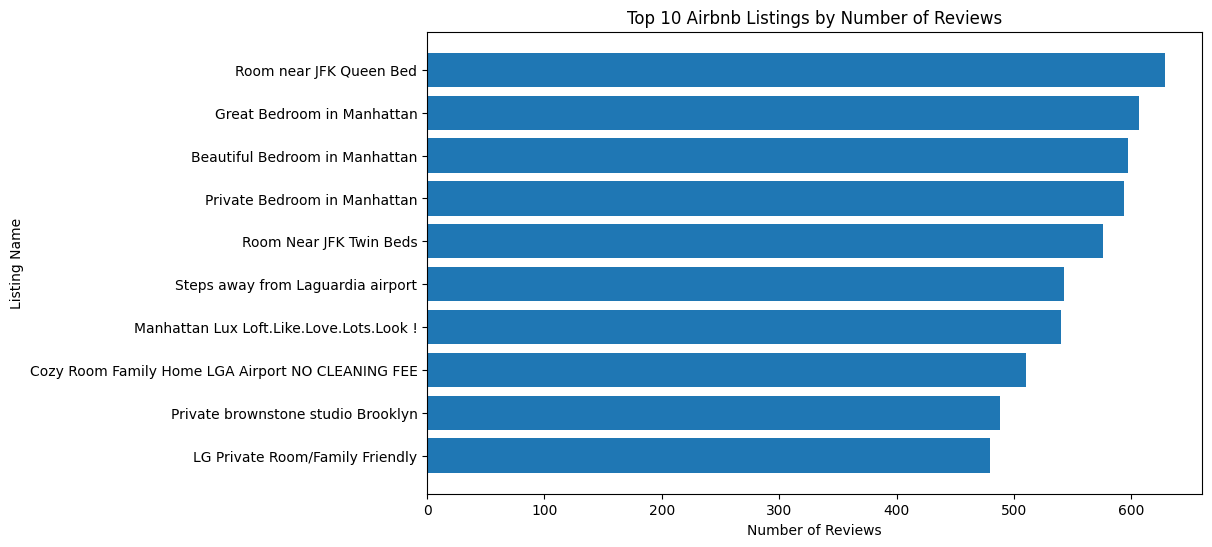

In [ ]:
plt.figure(figsize=(10,6))
top_reviewed_sorted = top_reviewed.sort_values('number_of_reviews')
plt.barh(top_reviewed_sorted['name'].astype(str), top_reviewed_sorted['number_of_reviews'])
plt.title('Top 10 Airbnb Listings by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Listing Name')
plt.show()

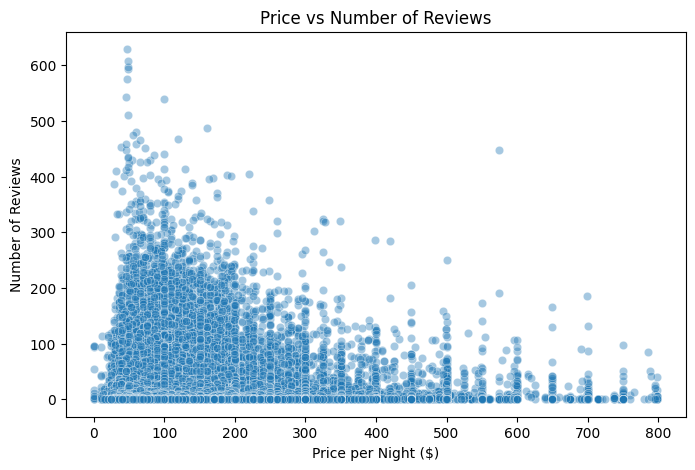

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_price, x='price', y='number_of_reviews', alpha=0.4)
plt.title('Price vs Number of Reviews')
plt.xlabel('Price per Night ($)')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
correlation = df_clean[numeric_cols].corr()
correlation

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,0.042799,-0.047954,-0.050564,0.057472,0.081829
minimum_nights,0.042799,1.000000,-0.080116,-0.124905,0.127960,0.144303
number_of_reviews,-0.047954,-0.080116,1.000000,0.589407,-0.072376,0.172028
reviews_per_month,-0.050564,-0.124905,0.589407,1.000000,-0.047312,0.163732
calculated_host_listings_count,0.057472,0.127960,-0.072376,-0.047312,1.000000,0.225701
availability_365,0.081829,0.144303,0.172028,0.163732,0.225701,1.000000


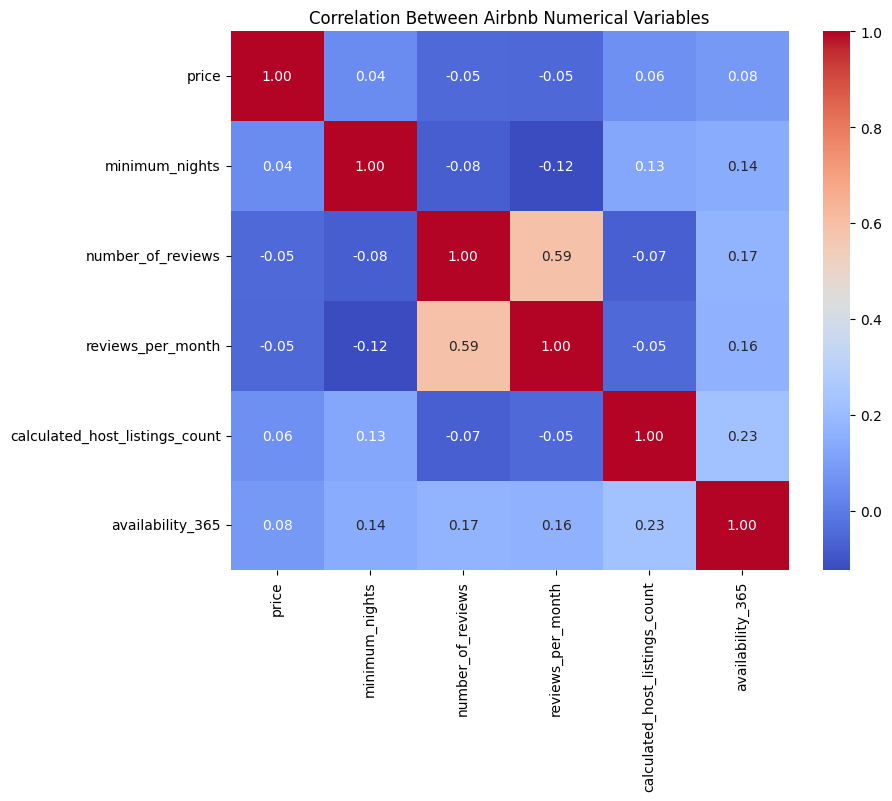

In [ ]:
plt.figure(figsize=(9,7))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Airbnb Numerical Variables')
plt.show()

In [ ]:
print("=" * 60)
print("AIRBNB DATA ANALYSIS - PROJECT CONCLUSION")
print("=" * 60)

print("\nKey Findings:")

print("\n1. Dataset:")
print("The dataset contains 48,895 Airbnb listings across New York City.")

print("\n2. Room Types:")
print("Entire home/apt is the most common room type, with 25,409 listings.")
print("Private rooms are the second most common with 22,326 listings.")

print("\n3. Pricing:")
print("The average Airbnb price is approximately $152.72 per night.")
print("The original dataset contains prices ranging from $0 to $10,000.")

print("\n4. Price Distribution:")
print("The price distribution is right-skewed because a small number of listings")
print("have exceptionally high prices.")

print("\n5. Neighbourhood:")
print("Williamsburg has the highest number of listings among the top")
print("10 neighbourhoods analyzed.")

print("\n6. Room Type and Price:")
print("Entire home/apt listings generally have higher prices than")
print("private and shared rooms.")

print("\n7. Analysis:")
print("Neighbourhood, room type, price, reviews and availability were")
print("analyzed using exploratory data analysis.")

print("\n" + "=" * 60)
print("OVERALL CONCLUSION")
print("=" * 60)

print("""
This project demonstrates how Python can be used for exploratory
data analysis of Airbnb listings. The analysis included data cleaning,
handling missing values, identifying extreme prices, statistical analysis,
and data visualization.
""")

AIRBNB DATA ANALYSIS - PROJECT CONCLUSION

Key Findings:

1. Dataset:
The dataset contains 48,895 Airbnb listings across New York City.

2. Room Types:
Entire home/apt is the most common room type, with 25,409 listings.
Private rooms are the second most common with 22,326 listings.

3. Pricing:
The average Airbnb price is approximately $152.72 per night.
The original dataset contains prices ranging from $0 to $10,000.

4. Price Distribution:
The price distribution is right-skewed because a small number of listings
have exceptionally high prices.

5. Neighbourhood:
Williamsburg has the highest number of listings among the top
10 neighbourhoods analyzed.

6. Room Type and Price:
Entire home/apt listings generally have higher prices than
private and shared rooms.

7. Analysis:
Neighbourhood, room type, price, reviews and availability were
analyzed using exploratory data analysis.

OVERALL CONCLUSION

This project demonstrates how Python can be used for exploratory
data analysis of Airbnb 

In [ ]:
# Save the cleaned Airbnb dataset

df_clean.to_csv("Airbnb_Cleaned_Data.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File name: Airbnb_Cleaned_Data.csv")

Cleaned dataset saved successfully!
File name: Airbnb_Cleaned_Data.csv


In [ ]:
results = {"Total Listings": len(df_clean), "Average Price": df_clean['price'].mean(), "Minimum Price": df_clean['price'].min(), "Maximum Price": df_clean['price'].max(), "Most Common Room Type": df_clean['room_type'].mode()[0], "Most Common Neighbourhood": df_clean['neighbourhood'].mode()[0]}
results_df = pd.DataFrame([results])
results_df.to_csv("Airbnb_Analysis_Results.csv", index=False)
print("Analysis results saved successfully!")
print(results_df)

Analysis results saved successfully!
   Total Listings  Average Price  Minimum Price  Maximum Price  \
0           48895     152.720687              0          10000   

  Most Common Room Type Most Common Neighbourhood  
0       Entire home/apt              Williamsburg  


In [ ]:
summary = pd.DataFrame({"Analysis": ["Total Listings", "Average Price", "Most Common Room Type", "Most Common Neighbourhood", "Most Reviewed Listing"], "Result": [len(df_clean), round(df_clean['price'].mean(), 2), df_clean['room_type'].mode()[0], df_clean['neighbourhood'].mode()[0], df_clean.loc[df_clean['number_of_reviews'].idxmax(), 'name']]})
summary

,Analysis,Result
0,Total Listings,48895
1,Average Price,152.72
2,Most Common Room Type,Entire home/apt
3,Most Common Neighbourhood,Williamsburg
4,Most Reviewed Listing,Room near JFK Queen Bed


In [ ]:
# Step 15: Final Summary

summary = pd.DataFrame({
    "Analysis": [
            "Total Listings",
                    "Average Price",
                            "Most Common Room Type",
                                    "Most Common Neighbourhood",
                                            "Most Reviewed Listing"
                                                ],
                                                    "Result": [
                                                            len(df_clean),
                                                                    round(df_clean['price'].mean(), 2),
                                                                            df_clean['room_type'].mode()[0],
                                                                                    df_clean['neighbourhood'].mode()[0],
                                                                                            df_clean.loc[df_clean['number_of_reviews'].idxmax(), 'name']
                                                                                                ]
                                                                                                })

summary